<a href="https://colab.research.google.com/github/JavierCarrillo12/Computacion-visual-jtorresle-jugomezra-dagarzonmo-jacarrillo/blob/main/Talleres/2025_07_04_taller_embeddings_visuales_clip_pca/colab/2025_07_04_taller_embeddings_visuales_clip_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install open-clip-torch ftfy torch scikit-learn==1.6.0 matplotlib --upgrade --quiet

In [ ]:
import torch
import open_clip
import numpy as np
from PIL import Image
from torchvision.datasets import CIFAR10
from torch.utils.data import Subset
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [12]:
import open_clip, torch
import torch
from PIL import Image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
model, _, preprocess = open_clip.create_model_and_transforms('ViT-H-14', pretrained='laion2b_s32b_b79k')


In [13]:
# 2. Descarga CIFAR-10 y filtra un subconjunto variado
#    Clases en CIFAR-10: 0=airplane, 1=automobile, 2=bird, 3=cat,
#                       4=deer, 5=dog, 6=frog, 7=horse, 8=ship, 9=truck
wanted = [3, 5, 1, 9, 7]      # cat, dog, automobile, truck, horse
per_class = 5               # cuántas imágenes por clase
dataset = CIFAR10("data/", train=True, download=True)
labels = np.array(dataset.targets)

idxs = []
for cls in wanted:
    cls_idxs = np.where(labels == cls)[0]
    idxs += list(np.random.choice(cls_idxs, per_class, replace=False))

subset = Subset(dataset, idxs)


In [14]:
# 3. Preprocesa y crea el batch para CLIP
images = [subset[i][0] for i in range(len(subset))]  # PIL.Image
paths  = [f"{dataset.classes[subset[i][1]]}_{i}.png" for i in range(len(subset))]
batch  = torch.cat([preprocess(img).unsqueeze(0) for img in images]).to(device)


In [ ]:
# with torch.no_grad():
#     image_features = [model.encode_image(img).cpu().numpy() for img in images]
# X = np.vstack(image_features)

In [15]:
with torch.no_grad():
    feats = model.encode_image(batch).cpu().numpy()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# X_pca = PCA(n_components=2).fit_transform(feats)
# # o
# X_tsne = TSNE(n_components=2, perplexity=30).fit_transform(feats)


In [16]:
X2 = PCA(n_components=2).fit_transform(feats)

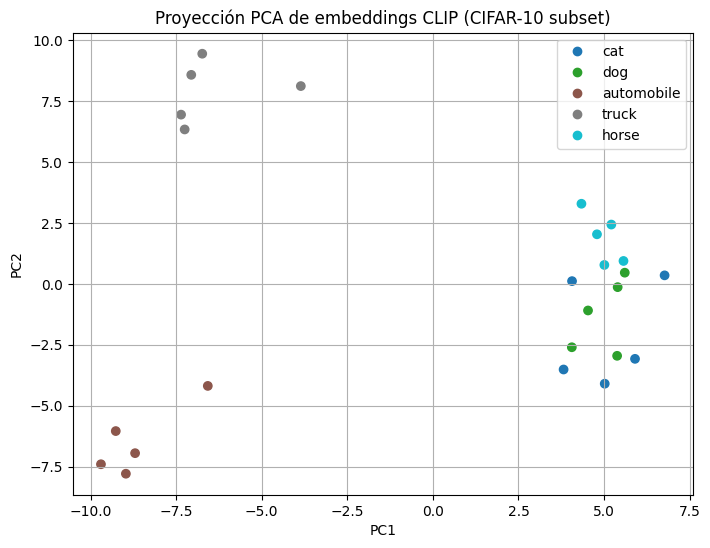

In [17]:
# 6. Graficar
plt.figure(figsize=(8,6))
scatter = plt.scatter(X2[:,0], X2[:,1], c=[wanted.index(dataset.targets[idx]) for idx in idxs], cmap="tab10")
plt.legend(handles=scatter.legend_elements()[0], labels=[dataset.classes[c] for c in wanted])
plt.title("Proyección PCA de embeddings CLIP (CIFAR-10 subset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()